# Integrated signature scoring

**PCA、zscore 与 ssGSEA 联合评分**

Score the public IMvigor210 demonstration matrix (872 features × 348 samples). This is a restricted feature panel, not a complete transcriptome; only signatures with sufficient overlap are returned.

This notebook uses public [IOBR release fixtures](https://github.com/IOBR/IOBR/releases/tag/data-v1.0). Source URLs and checksums are in [data/manifest.json](data/manifest.json). Figures are descriptive; no clinical outcome labels are supplied.

**Setup:** from the repository root, install with `python -m pip install ".[tutorials]"`. Restart the notebook kernel after installation.

In [1]:
%matplotlib inline
from pathlib import Path
from time import perf_counter
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import iobrx

# Works from the repository root or from the tutorials directory.
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "tutorials" / "_common.py").exists())
sys.path.insert(0, str(ROOT / "tutorials"))
from _common import (configure, load, tpm_input, runtime_info, numeric_scores,
                     short_samples, clean_labels, panel, heatmap, scatter,
                     stacked, composition_figure, fractions, save_figure, save_result, COLORS, TEAL, RUST, NAVY)
configure(2)
iobrx.set_threads(8)
display(runtime_info())


{'iobrx': '0.2.0',
 'threads': 8,
 'native_available': True,
 'native_reason': None,
 'sorting': 'numpy CPU dispatch',
 'requires_avx512': False,
 'bundled_openblas_found': True,
 'versions': {'numpy': '2.2.6',
  'pandas': '2.3.3',
  'scipy': '1.16.3',
  'scikit-learn': '1.7.2',
  'iobrpy': '0.2.1',
  'gseapy': '1.3.1',
  'matplotlib': '3.10.9'}}

## 1. Inspect the input / 检查输入

Expression matrices are **genes × samples**. The analysis uses every sample; any figure subset is stated explicitly.

In [2]:
expression = load("imvigor210_eset")
input_shape = expression.shape
display(expression.iloc[:5, :4])


,SAMf2ce197162ce,SAM698d8d76b934,SAMc1b27bc16435,SAM85e41e7f33f9
rownames,,,,
LOC100093631,3.100940,2.820764,3.705899,2.810128
LOC100126784,-2.623775,-4.256052,-5.410445,-2.076004
LOC100128108,-1.501784,0.520052,-0.766588,-2.076004
LOC100128288,-0.336198,-1.220428,-1.951013,-1.258868
LOC100128361,0.254547,0.292385,-0.200991,-0.025377


## 2. Run the analysis / 运行分析

The timer covers the call below, including its resource setup. Data loading above and plotting below are excluded. This is a single run; repeated benchmark medians are reported separately in the README.

In [3]:
started = perf_counter()
result = iobrx.calculate_sig_score(expression, "signature_collection", method="integration", mini_gene_count=3, adjust_eset=True, n_threads=8)
elapsed = perf_counter() - started
display(save_result(result, "06_signature_integration", elapsed, input_shape))

Completed in 0.794 s; input 872 features × 348 samples.


,analysis,seconds,input_shape,output_shapes,threads
0,06_signature_integration,0.793958,"[872, 348]","{'result': [348, 178]}",8


In [4]:
display(result.head() if isinstance(result, pd.DataFrame) else {key: value.shape if isinstance(value, pd.DataFrame) else list(value) for key, value in result.items()})

,ID,CD_8_T_effector_PCA,DDR_PCA,APM_PCA,Immune_Checkpoint_PCA,CellCycle_Reg_PCA,Pan_F_TBRs_PCA,Histones_PCA,EMT1_PCA,EMT2_PCA,...,TIP_Priming_and_activation_2_ssGSEA,TIP_Recognition_of_cancer_cells_by_T_cells_1_ssGSEA,TIP_Recognition_of_cancer_cells_by_T_cells_2_ssGSEA,TMEscoreA_CIR_ssGSEA,TMEscoreA_plus_ssGSEA,TMEscoreB_CIR_ssGSEA,T_cell_inflamed_GEP_Ayers_et_al_ssGSEA,Th2_cells_Bindea_et_al_ssGSEA,WNT_target_ssGSEA,TMEscore_CIR_ssGSEA
0,SAMf2ce197162ce,-1.584367,1.346774,-0.979769,-0.477971,1.605590,3.093213,0.069053,1.066880,2.198742,...,-0.003710,0.272243,-0.001924,0.192655,0.163834,0.309980,-0.003719,0.235835,0.361050,-0.117325
1,SAM698d8d76b934,-0.106237,6.119335,0.554620,0.431672,1.703881,-0.571979,1.155106,1.543544,0.567396,...,0.024596,0.277987,0.001032,0.249046,0.218228,0.259823,0.141133,0.300961,0.357223,-0.010777
2,SAMc1b27bc16435,1.341304,4.050033,-0.938559,-0.087938,0.736582,-1.100018,1.608123,-0.652714,-1.589814,...,0.019829,0.291672,0.014698,0.239532,0.232598,0.242714,0.070283,0.256001,0.395646,-0.003182
3,SAM85e41e7f33f9,2.503446,2.963588,1.014846,1.783894,1.333749,2.179296,1.470087,0.439613,2.723838,...,0.094806,0.298887,0.073934,0.296572,0.275354,0.294120,0.243592,0.297729,0.349563,0.002452
4,SAMf275eb859a39,0.338467,-3.981383,0.841926,-0.304024,-2.189340,-3.066415,-2.128893,-1.621112,-2.652536,...,0.015619,0.309181,0.031903,0.195194,0.193005,0.235284,0.102436,0.241019,0.369622,-0.040091


## 3. Visualize and export / 作图与导出

White background, restrained colors, thin axes and editable vector text. Heatmap z-scores are display-only; exported result tables keep the original values. `S01`, `S02`, … follow the sample order of each displayed matrix; the mapping is printed below.

For the IMvigor210 heatmaps, only the first 30 samples are shown (24 per panel in the integration notebook); scoring and distributions use all 348.

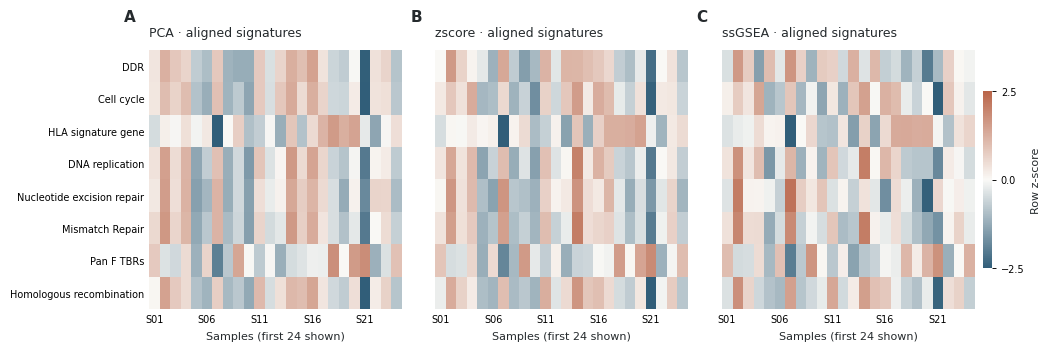

59 signatures are available in all three methods; display scaling is applied independently to each row.


In [5]:
scores = numeric_scores(result).astype(float)
suffixes = ["_PCA", "_zscore", "_ssGSEA"]
common = sorted(set(c[:-4] for c in scores if c.endswith("_PCA")) & set(c[:-7] for c in scores if c.endswith("_zscore")) & set(c[:-7] for c in scores if c.endswith("_ssGSEA")))
selected = sorted(common, key=lambda name: scores[name + "_PCA"].std(), reverse=True)[:8]
fig, axes = plt.subplots(1, 3, figsize=(10.4, 3.4), layout="constrained")
for ax, suffix, letter, title in zip(axes, suffixes, "ABC", ["PCA", "zscore", "ssGSEA"]):
    matrix = scores[[name + suffix for name in selected]].T
    matrix.index = selected
    heatmap(ax, matrix, max_rows=8, max_samples=24, row_labels=(letter == "A"), colorbar=(letter == "C"))
    panel(ax, letter, title + " · aligned signatures")
save_figure(fig, '06_signature_integration')
print(f"{len(common)} signatures are available in all three methods; display scaling is applied independently to each row.")


In [6]:
sample_ids = expression.columns if "expression" in globals() else counts.columns if "counts" in globals() else tpm.columns
display(pd.DataFrame({"plot_label": short_samples(sample_ids), "original_sample_id": sample_ids}).head(30))

,plot_label,original_sample_id
0,S01,SAMf2ce197162ce
1,S02,SAM698d8d76b934
2,S03,SAMc1b27bc16435
3,S04,SAM85e41e7f33f9
4,S05,SAMf275eb859a39
5,S06,SAM7f0d9cc7f001
6,S07,SAM4305ab968b90
7,S08,SAMcf018fee2acd
8,S09,SAMb2f1d0e54ece
9,S10,SAMcc4675f394a1


## 4. Interpretation and limits / 解读与边界

Integration concatenates method-specific scores with _PCA, _zscore and _ssGSEA suffixes. It does not average them into a new biological score. Different methods have different units and should not be compared by raw magnitude.

**Reusing this tutorial:** replace the input-loading cell with your own `pd.read_csv(..., index_col=0)`; keep the matrix orientation, identifier type and expression scale consistent with this example. Check gene overlap before interpreting estimates.

Figures are written to `tutorials/figures/06_signature_integration.png`, `.pdf`, and `.svg`. Compact output tables and timing metadata are written to `tutorials/results/`. Large count/TPM matrices remain in `result`; save them explicitly with `result.to_parquet(...)` if needed.